In [106]:
import matplotlib.pyplot as plt
from astropy import units as u
import pandas as pd
import os
from astropy.io import fits
from spectral_cube import SpectralCube
from velocity_tools import extract_streamline, gradient_descent, stream_lines_grad
import jax
import jax.numpy as jnp


In [107]:
# function to find spikes in the loss
def find_spikes(loss, threshold=0.1):
    spikes = []
    for i in range(1, len(loss) - 1):
        if loss[i] > loss[i - 1] * (1 + threshold) and loss[i] > loss[i + 1] * (1 + threshold):
            spikes.append(i)
    return spikes

Spikes found at epochs: [35, 56, 68]


Text(0, 0.5, 'Loss')

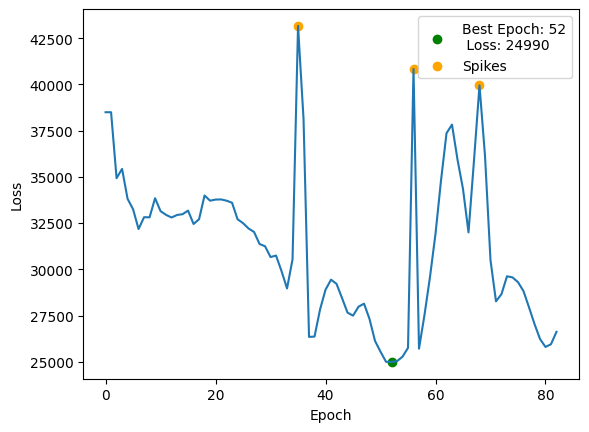

In [108]:
# import data
optimisation_log = pd.read_csv("streamfit_test_output/optimisation_log.csv")
optimisation_log

epochs = optimisation_log["epoch"].values
loss = optimisation_log["loss"].values

lowest_loss = min(loss)
best_epoch = epochs[loss.argmin()]

spikes = find_spikes(loss, threshold=0.1)
print(f"Spikes found at epochs: {spikes}")

plt.plot(epochs, loss)
plt.scatter(best_epoch, lowest_loss, color="green", label=f"Best Epoch: {best_epoch}\n Loss: {lowest_loss:.0f}")
plt.scatter(epochs[spikes], loss[spikes], color="orange", label="Spikes")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")


We want to investigate which change in parameters causes the spikes in loss

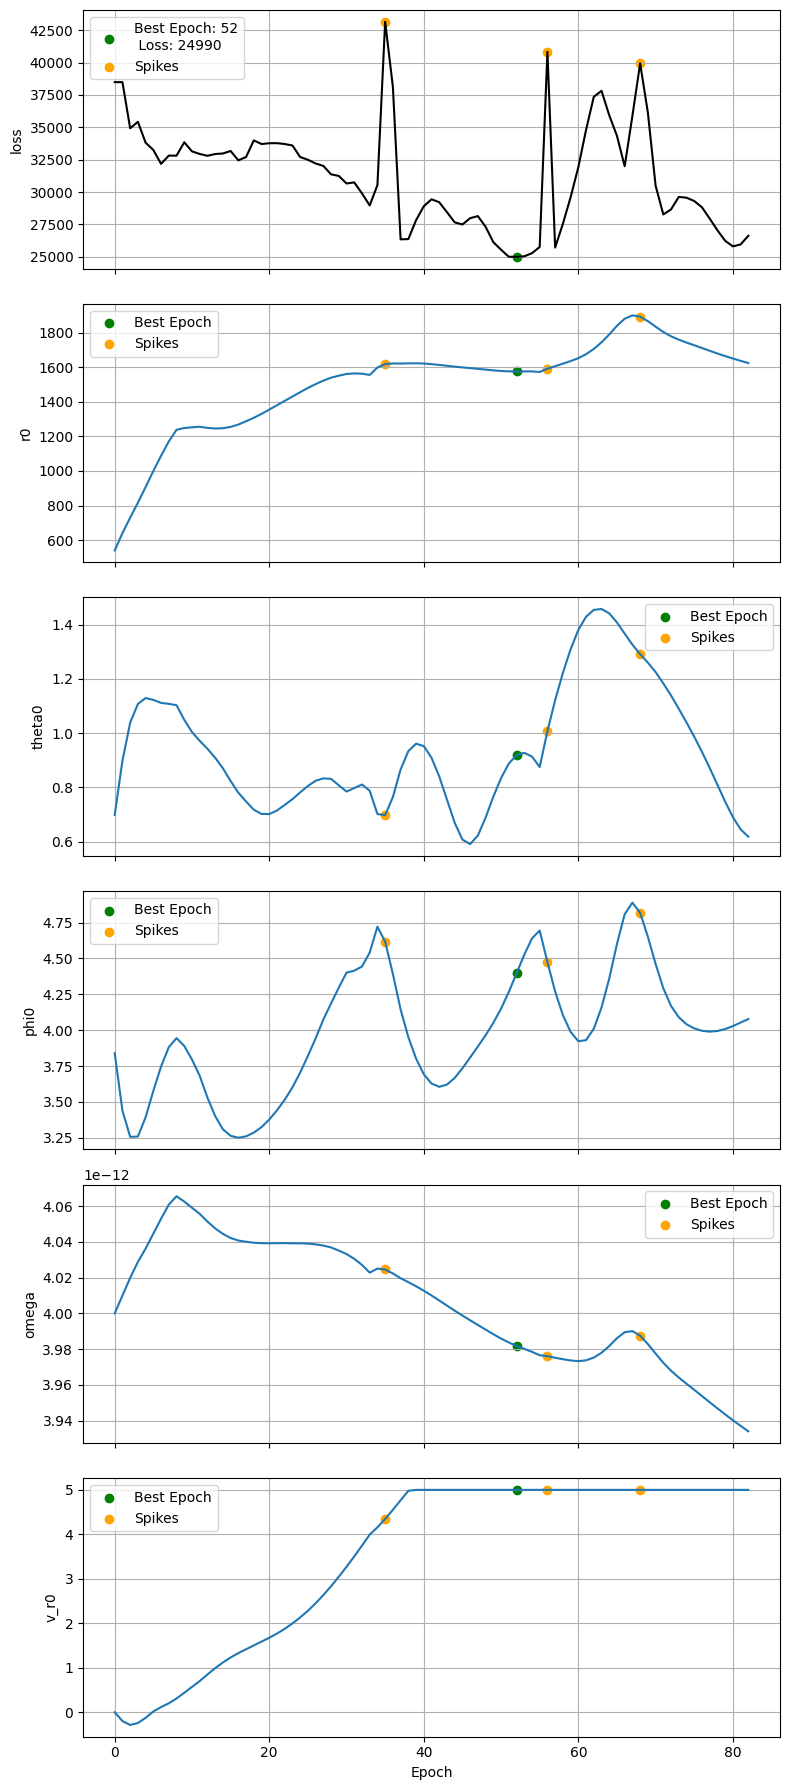

In [109]:
# plot the parameters over epochs in a single figure with subplots
param_names = [col for col in optimisation_log.columns if col not in ("epoch", "loss")]

fig, axes = plt.subplots(len(param_names) + 1, 1, figsize=(8, 3 * (len(param_names) + 1)), sharex=True)
loss_ax = axes[0]
loss_ax.plot(epochs, loss, color="black")
loss_ax.scatter(best_epoch, lowest_loss, color="green", label=f"Best Epoch: {best_epoch}\n Loss: {lowest_loss:.0f}")
loss_ax.scatter(epochs[spikes], loss[spikes], color="orange", label="Spikes")
loss_ax.set_ylabel("loss")
loss_ax.grid(True)
loss_ax.legend()

for ax, param in zip(axes[1:], param_names):
    param_values = optimisation_log[param].values
    ax.plot(epochs, param_values)
    ax.scatter(best_epoch, param_values[loss.argmin()], color="green", label="Best Epoch")
    ax.scatter(epochs[spikes], param_values[spikes], color="orange", label="Spikes")
    ax.set_ylabel(param)
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Epoch")
fig.tight_layout()
plt.show()

Plot the model at every epoch

In [110]:
# get the point cloud first
cubefile = 'test_data/HLTAU_HCOp32.fits'
# get the spectralcube object from the data using spectral-cube
hdu = fits.open(cubefile)[0]
cube = SpectralCube.read(hdu).with_spectral_unit(u.km/u.s, rest_value=hdu.header['RESTFRQ']*u.Hz)

print("Loaded cube with shape:", cube.shape)

# TODO: this streamer extraction should be replaced with clustering-based streamer extraction

# extract the subcube with the streamer (we got this from the tipsy tutorial, no need to plot)
## Limits for extracting subcube with streamer
vmin = 7    # Min. vel. of streamer
vmax = 10
xmin = -3   # Min R.A. offset (arcsec) to consider for streamer
xmax = -1
ymin = -3   # Min. Decl. offset (arcsec) to consider for streamer
ymax = 0.5
rms_thresh = 4  # sigma threshold for streamer

# extract the streamer subcube
info_header = cube.header  # header of the cube, contains required information
x_conv_fac = 1/60/60/info_header['CDELT1']
xmin_p = int((xmin*x_conv_fac)+info_header['CRPIX1'])
xmax_p = int((xmax*x_conv_fac)+info_header['CRPIX1'])
y_conv_fac = 1/60/60/info_header['CDELT2']
ymin_p = int((ymin*y_conv_fac)+info_header['CRPIX2'])
ymax_p = int((ymax*y_conv_fac)+info_header['CRPIX2'])
vunit = cube.spectral_axis.unit
## Note: a check can be added to see if requested limits are within the limits of the cube itself

streamer_cubev = cube.spectral_slab(vmin*vunit,vmax*vunit)    # Selecting velocities
streamer_cubevc = streamer_cubev[:,min(ymin_p,ymax_p):max(ymin_p,ymax_p)   
                    ,min(xmin_p,xmax_p):max(xmin_p,xmax_p)]   # Selecting pixels
#     print(min(ymin_p,ymax_p),max(ymin_p,ymax_p),min(xmin_p,xmax_p),max(xmin_p,xmax_p)) 
streamer_cube = streamer_cubevc.with_mask(streamer_cubevc > rms_thresh*streamer_cubevc.mad_std())  # Removing low flux values 

n_points = 10 # the number of points we want to reduce the data to


# Extract 1D streamline from the data cube
pc_coords, pc_means, pc_stds = extract_streamline.reduce_to_1D(streamer_cube, n_elements=n_points)

# Prepare data for gradient descent
ra_data = pc_means[0] # offsets in arcsec
dec_data = pc_means[1] # offsets in arcsec
v_data = pc_means[2]   # velocities in km/s (rel to vlsr)

ra_sigma = pc_stds[0]
dec_sigma = pc_stds[1]
v_sigma = pc_stds[2]


data = (ra_data, dec_data, v_data)
uncertainties = (ra_sigma, dec_sigma, v_sigma)

Loaded cube with shape: (500, 401, 401)
Starting reduction
Created coordinate arrays


Got point cloud with 14974 points
Partition boundaries for projected distance metric: [1.031 1.122 1.176 1.234 1.3   1.383 1.48  1.602 1.732 1.898 3.251]


{'r0': 540.0, 'theta0': 0.6981317007977318, 'phi0': 3.839724354387525, 'omega': 4e-12, 'v_r0': 0.0}
{'mass': 3.2, 'inc': -0.8203047513961792, 'pa': 2.4085543155670166, 'rmin': 50.0, 'deltar': 40.0, 'v_lsr': 7}
[-0.46134412 -0.47998008 -0.50097847 -0.5261944  -0.56060755] [-0.9003769  -0.9444872  -0.99418914 -1.0538738  -1.1373712 ] [9.168517 9.062207 8.942419 8.798573 8.610359]


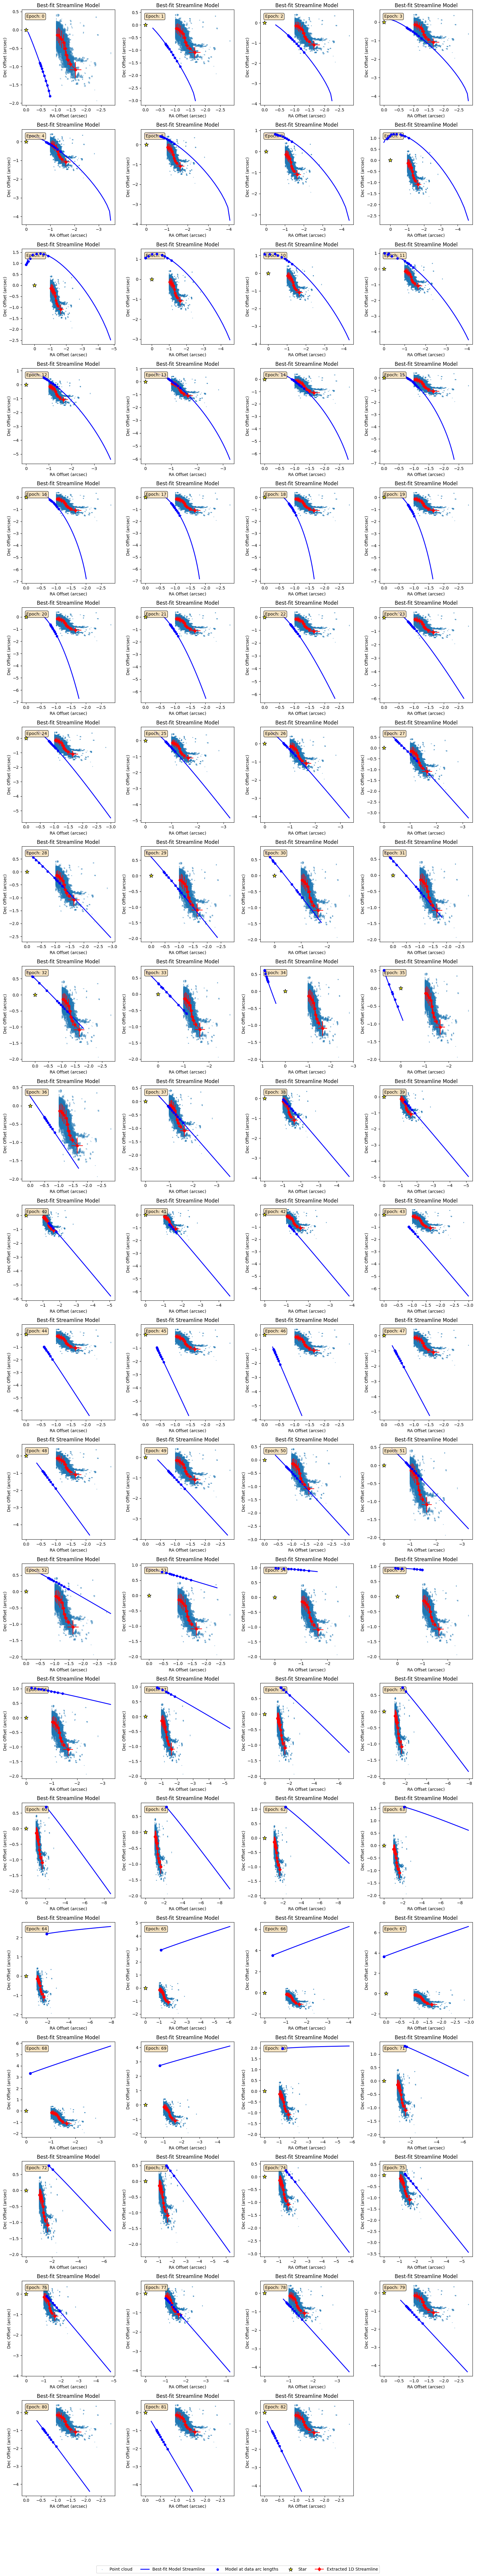

In [113]:
# Fixed parameters (not optimized)
fixed_params = {
    'mass': 3.2,  # Msun
    'inc': -47.0,  # degrees
    'pa': 138.0,  # degrees
    'rmin': 50.0,  # au
    'deltar': 40.0,  # au
    'v_lsr': 7  # km/s (systemic velocity)
}
distance = 147 # pc

# Convert fixed angle params to radians to match forward_model expectations
fixed_params['inc'] = float(jnp.deg2rad(fixed_params['inc']))
fixed_params['pa'] = float(jnp.deg2rad(fixed_params['pa']))

# Create subplots - calculate grid dimensions
num_epochs = len(epochs)
n_cols = 4
n_rows = (num_epochs + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

for idx, epoch in enumerate(epochs):
    ax = axes[idx]
    # Use the row corresponding to this plotted epoch
    row = optimisation_log.iloc[idx]
    opt_params_epoch = {param: float(row[param]) for param in param_names}

    ra_model, dec_model, v_model = gradient_descent.forward_model(opt_params_epoch, fixed_params, distance)
    # remove NaN values (due to rmin) from model
    not_nan = ~jnp.isnan(ra_model) & ~jnp.isnan(dec_model) & ~jnp.isnan(v_model)
    ra_model = ra_model[not_nan]
    dec_model = dec_model[not_nan]
    v_model = v_model[not_nan]

    # get the model positions at data arc length points
    ra_model_interp, dec_model_interp, v_model_interp, valid = gradient_descent.match_model_to_data_curve(
        ra_model, dec_model, v_model, ra_data, dec_data)
    if idx == 0:  # only print for the first epoch to avoid clutter
        print(opt_params_epoch)
        print(fixed_params)
        print(ra_model_interp[:5], dec_model_interp[:5], v_model_interp[:5])

    # mask for valid (only for arrays that haven't already been masked in matching)
    v_data_valid = v_data[valid]
    ra_sigma_valid = ra_sigma[valid]
    dec_sigma_valid = dec_sigma[valid]
    v_sigma_valid = v_sigma[valid]

    # plot it on top of the data
    ax.scatter(pc_coords[0], pc_coords[1], s=1, alpha=0.3, label='Point cloud')
    # plot the extracted 1D data streamline with error bars
    ax.errorbar(ra_data, dec_data, xerr=ra_sigma_valid, yerr=dec_sigma_valid, fmt='o-', label='Extracted 1D Streamline', color='red')
    # plot the best-fit model streamline
    ax.plot(ra_model, dec_model, color='blue', linewidth=2, label='Best-fit Model Streamline')
    # plot the model positions at data arc length points
    ax.scatter(ra_model_interp, dec_model_interp, s=25, label='Model at data arc lengths', color='blue', zorder=5)
    # plot the star
    ax.scatter(0, 0, marker='*', s=100, color='yellow', edgecolor='black', label='Star', zorder=10)
    # invert x axis to match RA offset direction
    ax.invert_xaxis()
    ax.set_xlabel('RA Offset (arcsec)')
    ax.set_ylabel('Dec Offset (arcsec)')
    ax.set_title('Best-fit Streamline Model')
    # Add epoch annotation
    ax.text(0.05, 0.95, f"Epoch: {int(epoch)}", transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Hide any unused subplots
for idx in range(num_epochs, len(axes)):
    axes[idx].axis('off')

# Create a single legend from the first subplot's handles and labels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=5, frameon=True)

fig.tight_layout()
plt.savefig("streamfit_test_output/streamline_fits_over_epochs.png", bbox_inches='tight')
plt.show()